In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42

In [2]:
DATA_PATH = "../data/default of credit card clients.xls"

df = pd.read_excel(DATA_PATH, header=1)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df.shape # 23 predictors + ID + target

(30000, 25)

In [4]:
df.columns.tolist() # names of the predictors

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [5]:
# We simplify the target: from default payment next month to DEFAULT
df = df.rename(
    columns={"default payment next month": "DEFAULT"}
)

In [10]:
df["DEFAULT"].value_counts() # Counts number of observations of each class of the target (0: no default, 1: default)

DEFAULT
0    23364
1     6636
Name: count, dtype: int64

In [11]:
df["DEFAULT"].value_counts(normalize=True) # The same, but it returns proportions instead of absolute magnitudes

DEFAULT
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [12]:
# ID is just an identifier of the client. it's not an economic charasteristic that should be use to predict default
X = df.drop(columns=["ID", "DEFAULT"])
y = df["DEFAULT"]

In [13]:
# Train / test split. IMPORTANT: The rest of the models, like Logistic Regression and XGBoost have to use the same one
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,  # Keeps approximately the same percentage of defaults in Train and Test
    random_state=RANDOM_STATE
)

In [14]:
# It should be Train: 24,000 and Test:   6,000
print(X_train.shape)
print(X_test.shape)

print(y_train.mean())
print(y_test.mean())

(24000, 23)
(6000, 23)
0.22120833333333334
0.22116666666666668


In [15]:
# PREPROCESSING
# Very important because each predictor has a different scale, and neuronal netowrks (NN) are sensible to scale. 
# E.g. AGE ≈ 20–80, LIMIT_BAL ≈ Tens/hundreds of thousands, BILL_AMT1 ≈ Tens/hundreds of thousands, PAY_AMT1 ≈ thousands
# We must standarize

# ==============================================================================
# 1. FEATURE PARTITIONING
# ==============================================================================
# Explicitly identify nominal categorical variables.
# In the UCI dataset, these columns use numeric codes (e.g., SEX: 1=Male, 2=Female).
# We must treat them as distinct categories, not ordinal numbers with mathematical order.
categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
]

# Every column that isn't categorical is treated as numeric (e.g., LIMIT_BAL, AGE,
# payment histories PAY_0-PAY_6, and bill/payment amounts BILL_AMT*, PAY_AMT*).
numeric_features = [
    col for col in X.columns 
    if col not in categorical_features
]


# ==============================================================================
# 2. DEFINING THE PREPROCESSING PIPELINE
# ==============================================================================
# ColumnTransformer applies specific transformations to specific subsets of columns
# and stitches the resulting arrays back together into a single feature matrix.
preprocessor = ColumnTransformer(
    transformers=[
        # Pipeline 1: Scale numeric variables
        # Centers data at mean 0 with standard deviation 1.
        # Essential for Logistic Regression and Neural Networks so that large values
        # (like LIMIT_BAL = 500,000) don't dominate small values (like PAY_0 = 2).
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        
        # Pipeline 2: Convert categories to one-hot binary flags (0 or 1)
        # - handle_unknown="ignore": Prevents code crashes if an unseen category appears in test data.
        # - sparse_output=False: Produces a dense NumPy array (required by SHAP and LIME).
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
    ],
    # verbose_feature_names_out=False keeps output names clean 
    # (e.g., "SEX_1" instead of "categorical__SEX_1").
    verbose_feature_names_out=False
)


# ==============================================================================
# 3. FITTING AND TRANSFORMING (PREVENTING DATA LEAKAGE)
# ==============================================================================
# Step A: fit_transform() on the TRAINING data ONLY.
# - 'fit': Learns the mean/std dev and unique categories from X_train.
# - 'transform': Converts X_train using those learned parameters.
X_train_processed = preprocessor.fit_transform(X_train)

# Step B: transform() on the TEST data.
# Uses the training parameters (mean/std) to scale the test data.
# NEVER call fit() on test data; doing so leaks test distribution into the training pipeline.
X_test_processed = preprocessor.transform(X_test)

# We check the result
X_train_processed.shape
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX_1', 'SEX_2',
       'EDUCATION_0', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3',
       'EDUCATION_4', 'EDUCATION_5', 'EDUCATION_6', 'MARRIAGE_0',
       'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3'], dtype=object)

This configuration specifies a feedforward Multilayer Perceptron (MLP) for binary classification on the preprocessed tabular credit dataset (33 input features).

---

#### 1. Network Architecture
* **`hidden_layer_sizes=(64, 32)`**: The first hidden layer projects the 33 preprocessed features into a 64-dimensional latent space to model feature interactions; the second layer compresses this representation to 32 dimensions prior to the binary output node.
* **`activation="relu"`**: Rectified Linear Unit ($f(x) = \max(0, x)$). Introduces non-linearity across hidden units while mitigating vanishing gradients during backpropagation.

---

#### 2. Optimization
* **`solver="adam"`**: Adaptive Moment Estimation. Dynamically updates weights using exponentially decaying running averages of past gradients and squared gradients.
* **`learning_rate_init=0.001`**: Initial step size for the Adam optimizer.
* **`batch_size=256`**: Mini-batch size per gradient update. Balances vectorized computation throughput against stochastic gradient noise.
* **`max_iter=300`**: Hard ceiling on the total number of training epochs.

---

#### 3. Regularization & Convergence
* **`alpha=0.0001`**: $L_2$ penalty parameter (weight decay). Penalizes large weight magnitudes ($\frac{1}{2} \alpha \Vert{}w\Vert{}_2^2$) to constrain model complexity and reduce overfitting.
* **`early_stopping=True`**: Terminates optimization when out-of-sample generalization performance stops improving.
* **`validation_fraction=0.15`**: Reserves 15% of the training partition strictly as an internal holdout set for early stopping evaluation.
* **`n_iter_no_change=20`**: Early stopping patience. Optimization terminates if validation loss fails to decrease for 20 consecutive epochs.

---

#### 4. Execution Controls
* **`random_state=RANDOM_STATE`**: Fixes the pseudo-random seed for weight initialization, mini-batch shuffling, and validation splitting to ensure exact reproducibility.
* **`verbose=False`**: Suppresses epoch-level training logs to maintain clean notebook output.

In [16]:
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",

    alpha=0.0001,
    learning_rate_init=0.001,

    batch_size=256,

    max_iter=300,

    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,

    random_state=RANDOM_STATE,
    verbose=False
)

In [17]:
# TRAINING

nn_model.fit(
    X_train_processed,
    y_train
)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",256
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True.",0.15
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",20
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decr

In [18]:
print("Epochs:", nn_model.n_iter_)

Epochs: 31


In [20]:
# 0 -> non-default
# 1 -> default
y_pred_nn = nn_model.predict(
    X_test_processed
)

In [21]:
# Estimated probability of DEFAULT.
# E.g. Client 1 -> 0.08, Client 2 -> 0.21, Client 3 -> 0.72
y_proba_nn = nn_model.predict_proba(
    X_test_processed
)[:, 1]

In [22]:
# METRICS

# Function to compare all the models identically
def evaluate_classifier(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

nn_metrics = evaluate_classifier(
    y_test,
    y_pred_nn,
    y_proba_nn
)

pd.Series(nn_metrics)

Accuracy     0.817833
ROC-AUC      0.770647
Precision    0.660714
Recall       0.362472
F1           0.468127
dtype: float64

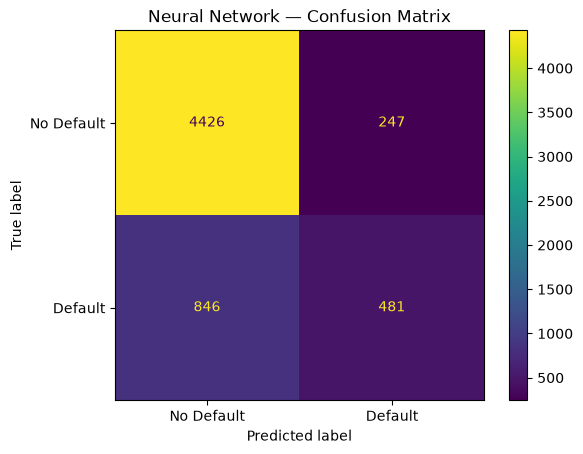

In [ ]:
# Confusion Matrix
# In particular, FN are really interesting: The model consider safe a client and that client ends up in DEFAULT
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nn,
    display_labels=["No Default", "Default"]
)

plt.title("Neural Network — Confusion Matrix")
plt.show()

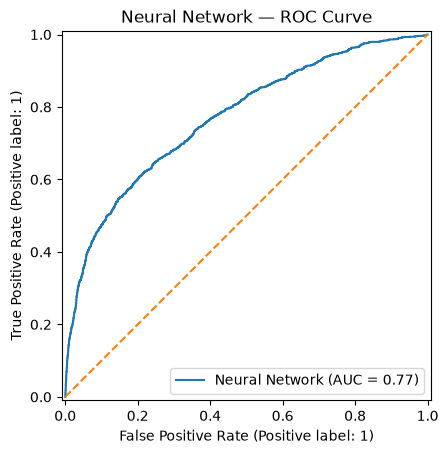

In [ ]:
# ROC Curve
# If you randomly pick one applicant who actually defaulted and one applicant who did not, ROC-AUC is the probability that the model assigns a higher default probability to the actual defaulter.
# AUC = 0.50: The model has no discriminatory power (equivalent to a coin flip).
# AUC = 0.75: There is a 75% chance the model scores a defaulter higher than a non-defaulter.
# AUC = 1.00: Perfect separation. Every single defaulter is scored higher than every non-defaulter.
RocCurveDisplay.from_predictions(
    y_test,
    y_proba_nn,
    name="Neural Network"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("Neural Network — ROC Curve")
plt.show()

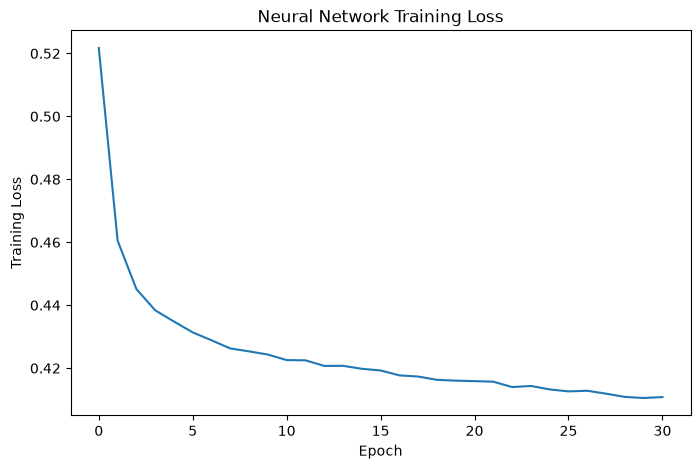

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(nn_model.loss_curve_)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Neural Network Training Loss")

plt.show()

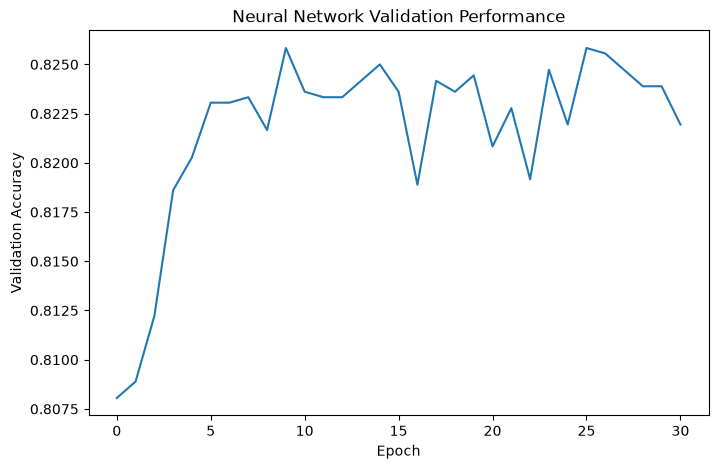

In [26]:
nn_model.validation_scores_

plt.figure(figsize=(8, 5))

plt.plot(nn_model.validation_scores_)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Neural Network Validation Performance")

plt.show()